In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/final_prepared.csv")

print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (15967, 13)
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0  -0.536500 -0.083419           -1.810808     1.515710        2.062013   
1   1.252960 -1.249045           -0.850301     0.456168        0.288378   
2   0.834256 -0.885370            0.430374    -0.394993       -0.444883   
3  -0.401917  1.091532            0.030163    -0.047381        0.121728   
4  -1.339016  1.012270           -0.049879     1.483223        2.531014   

   population  households  median_income  ocean_proximity_INLAND  \
0    1.322515    2.106897      -0.744240               -0.693663   
1    0.516142    0.326958       0.793395               -0.693663   
2    0.599058   -0.450124      -0.283111               -0.693663   
3   -0.285674    0.127437      -1.377645                1.441622   
4    1.036412    2.613576      -0.290847               -0.693663   

   ocean_proximity_ISLAND  ocean_proximity_NEAR BAY  \
0               -0.017699                 -0.352419   
1  

In [3]:
X = df.drop("median_house_value", axis=1).values
y = df["median_house_value"].values

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (15967, 12)
Target shape: (15967,)


In [4]:
class LinearRegressionSGD:
    def __init__(self, learning_rate=0.01, epochs=100, decay=True):
        self.lr = learning_rate
        self.epochs = epochs
        self.decay = decay
        self.w = None
        self.b = None
        self.loss_history = []

    def predict(self, X):
        return np.dot(X, self.w) + self.b

    def fit(self, X, y):
        m, n = X.shape
        self.w = np.zeros(n)
        self.b = 0

        for epoch in range(self.epochs):
            epoch_loss = 0
            indices = np.arange(m)
            np.random.shuffle(indices)

            for t, i in enumerate(indices):
                xi = X[i]
                yi = y[i]

                y_pred = np.dot(xi, self.w) + self.b
                error = y_pred - yi

                dw = 2 * xi * error
                db = 2 * error

                lr_t = self.lr / (1 + t) if self.decay else self.lr

                self.w -= lr_t * dw
                self.b -= lr_t * db

                epoch_loss += error**2

            self.loss_history.append(epoch_loss / m)

    def mse(self, X, y):
        return np.mean((self.predict(X) - y)**2)

In [5]:
sgd_model = LinearRegressionSGD(learning_rate=0.01, epochs=50, decay=True)
sgd_model.fit(X, y)

print("Final MSE:", sgd_model.mse(X, y))

Final MSE: 4707460689.204232


In [6]:
import os
os.makedirs("../results", exist_ok=True)

np.save("../results/sgd_loss.npy", sgd_model.loss_history)
print("Loss history saved, length:", len(sgd_model.loss_history))

Loss history saved, length: 50


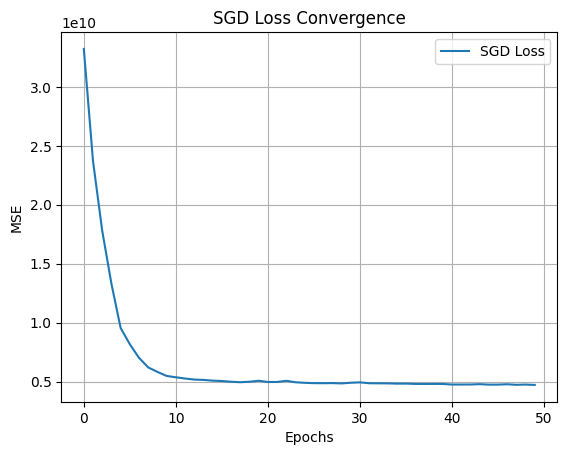

In [7]:
plt.plot(sgd_model.loss_history, label="SGD Loss")
plt.xlabel("Epochs")
plt.ylabel("MSE")
plt.title("SGD Loss Convergence")
plt.legend()
plt.grid(True)
plt.show()